# 05 — Helmholtz-Partitioned PV-Tendency Terms & Bootstrap Significance

This notebook projects **25 individual** PV-tendency terms onto the four-basis decomposition
(basis from **dh−1**, predictive framing) and uses **bootstrap resampling** for confidence
intervals and significance testing.

**5 wind groups** × 4 (bar/anom, zonal+merid or vert) = 20 advection + Q + dq/dt + 4 moist/dry div.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.decomposition.basis import PRENORM_PHI1

# ═══════════════════════════════════════════════════════════
#  Projection masking config (toggle on/off)
# ═══════════════════════════════════════════════════════════
USE_SIG_MASK   = True   # zero out non-significant pixels before projection
USE_NEG_PV_MASK = True  # restrict basis to q' < 0 region (mask_negative)

## 1  Discover and load all event files

In [2]:
DATA_ROOT = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE = "onset"
DH = 0
SMOOTH_DEG = 3.0
GRID_SP = 1.5

# Basis always from dh-1 (predictive framing)
DH_BASIS = max(DH - 1, -13)

sign = "+" if DH >= 0 else ""
npz_dir = f"{DATA_ROOT}/{STAGE}/dh={sign}{DH}"
npz_files = sorted(glob.glob(os.path.join(npz_dir, "track_*.npz")))

sign_b = "+" if DH_BASIS >= 0 else ""
npz_dir_b = f"{DATA_ROOT}/{STAGE}/dh={sign_b}{DH_BASIS}"
npz_files_b = sorted(glob.glob(os.path.join(npz_dir_b, "track_*.npz")))

print(f"Stage: {STAGE}   DH={DH} ({len(npz_files)} files)   "
      f"DH_BASIS={DH_BASIS} ({len(npz_files_b)} files)   "
      f"Smoothing: {SMOOTH_DEG}°")

Stage: onset   DH=0 (1260 files)   DH_BASIS=-1 (1260 files)   Smoothing: 3.0°


In [3]:
from zipfile import BadZipFile

def load_event(path):
    """Load an NPZ file and return a dict (None if corrupt/incomplete)."""
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None

def _load_all(file_list, label=""):
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(load_event, file_list))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ {label}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good

# Load events at DH (fields to project)
events = _load_all(npz_files, f"dh={DH}")
print(f"dh={DH}: {len(events)} events, shape={events[0]['pv_anom'].shape}")

# Load events at DH-1 (for basis construction)
events_basis = _load_all(npz_files_b, f"dh={DH_BASIS}")
print(f"dh={DH_BASIS} (basis): {len(events_basis)} events")

X_rel = events[0]["X_rel"]
Y_rel = events[0]["Y_rel"]
x_rel = X_rel[0, :]
y_rel = Y_rel[:, 0]

dh=0: 1260 events, shape=(29, 49)
dh=-1 (basis): 1260 events


## 2  Compute composite-mean basis fields (from dh−1)

In [4]:
# Average PV anomaly and its derivatives from dh-1 events (predictive framing)
pv_anom_mean = np.nanmean([e["pv_anom"] for e in events_basis], axis=0)
pv_dx_mean   = np.nanmean([e["pv_anom_dx"] for e in events_basis], axis=0)
pv_dy_mean   = np.nanmean([e["pv_anom_dy"] for e in events_basis], axis=0)

basis = compute_orthogonal_basis(
    pv_anom_mean, pv_dx_mean, pv_dy_mean,
    x_rel, y_rel,
    mask_negative=USE_NEG_PV_MASK,
    apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
)
print(f"Composite basis (from dh={DH_BASIS}) norms:",
      {k: f"{v:.4e}" for k, v in basis.norms.items()})
print(f"  mask_negative={USE_NEG_PV_MASK}  USE_SIG_MASK={USE_SIG_MASK}")

Composite basis (from dh=-1) norms: {'beta': '6.6119e+02', 'ax': '8.9056e+02', 'ay': '9.0170e+02', 'gamma': '4.8447e+02'}
  mask_negative=True  USE_SIG_MASK=True


## 3  Define individual RHS terms

In [5]:
# Term name → callable(event_dict) → 2-D field
# 21 terms = 5 groups × 4 bar/anom cross-terms + Q
# Groups: rot_bar (clim rot), div_bar (clim div),
#         anom_rot (anom rot), anom_div (anom div), vertical (ω)
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":  lambda e: e["pv_anom_dt"] + e["pv_bar_dt"],
    # ── Clim rotational (ū_rot) ──
    r"$-\bar{u}_{\psi}\,\bar{q}_x$":  lambda e: -e["u_rot_bar_pv_bar_dx"]  - e["v_rot_bar_pv_bar_dy"],
    r"$-\bar{u}_{\psi}\,q'_x$":       lambda e: -e["u_rot_bar_pv_anom_dx"] - e["v_rot_bar_pv_anom_dy"],
    # ── Clim divergent (ū_div) ──
    r"$-\bar{u}_{\chi}\,\bar{q}_x$":  lambda e: -e["u_div_bar_pv_bar_dx"]  - e["v_div_bar_pv_bar_dy"],
    r"$-\bar{u}_{\chi}\,q'_x$":       lambda e: -e["u_div_bar_pv_anom_dx"] - e["v_div_bar_pv_anom_dy"],
    # ── Anom rotational (u'_rot) ──
    r"$-u'_{\psi}\,\bar{q}_x$":       lambda e: -e["u_anom_rot_pv_bar_dx"]  - e["v_anom_rot_pv_bar_dy"],
    r"$-u'_{\psi}\,q'_x$":            lambda e: -e["u_anom_rot_pv_anom_dx"] - e["v_anom_rot_pv_anom_dy"],
    # ── Anom divergent (u'_div) ──
    r"$-u'_{\chi}\,\bar{q}_x$":       lambda e: -e["u_anom_div_pv_bar_dx"]  - e["v_anom_div_pv_bar_dy"],
    r"$-u'_{\chi}\,q'_x$":            lambda e: -e["u_anom_div_pv_anom_dx"] - e["v_anom_div_pv_anom_dy"],
    # ── Vertical (ω bar + anom × q bar + anom) ──
    r"$-\bar{\omega}\,\bar{q}_p$":    lambda e: -e["w_bar_pv_bar_dp"],
    r"$-\bar{\omega}\,q'_p$":         lambda e: -e["w_bar_pv_anom_dp"],
    r"$-\omega'\,\bar{q}_p$":         lambda e: -e["w_anom_pv_bar_dp"],
    r"$-\omega'\,q'_p$":              lambda e: -e["w_anom_pv_anom_dp"],
    # ── Moist/dry divergent partitions ──
    r"Moist div ($q'$)":               lambda e: -(e["u_div_moist_pv_anom_dx"] + e["v_div_moist_pv_anom_dy"]),
    r"Moist div ($\bar{q}$)":          lambda e: -(e["u_div_moist_pv_bar_dx"]  + e["v_div_moist_pv_bar_dy"]),
    r"Dry div ($q'$)":                 lambda e: -(e["u_div_dry_pv_anom_dx"]   + e["v_div_dry_pv_anom_dy"]),
    r"Dry div ($\bar{q}$)":            lambda e: -(e["u_div_dry_pv_bar_dx"]    + e["v_div_dry_pv_bar_dy"]),
    r"$-\omega_m\,q'_p$":              lambda e: -e["w_moist_pv_anom_dp"],
    r"$-\omega_m\,\bar{q}_p$":         lambda e: -e["w_moist_pv_bar_dp"],
    r"$-\omega_d\,q'_p$":              lambda e: -e["w_dry_pv_anom_dp"],
    r"$-\omega_d\,\bar{q}_p$":         lambda e: -e["w_dry_pv_bar_dp"],
    # ── Diabatic ──
    r"$Q$":                            lambda e: e["Q"],
}

TERM_NAMES = list(TERMS.keys())
print(f"{len(TERMS)} terms (incl. dq/dt + Q):", TERM_NAMES)

22 terms (incl. dq/dt + Q): ['$\\mathrm{d}q/\\mathrm{d}t$', '$-\\bar{u}_{\\psi}\\,\\bar{q}_x$', "$-\\bar{u}_{\\psi}\\,q'_x$", '$-\\bar{u}_{\\chi}\\,\\bar{q}_x$', "$-\\bar{u}_{\\chi}\\,q'_x$", "$-u'_{\\psi}\\,\\bar{q}_x$", "$-u'_{\\psi}\\,q'_x$", "$-u'_{\\chi}\\,\\bar{q}_x$", "$-u'_{\\chi}\\,q'_x$", '$-\\bar{\\omega}\\,\\bar{q}_p$', "$-\\bar{\\omega}\\,q'_p$", "$-\\omega'\\,\\bar{q}_p$", "$-\\omega'\\,q'_p$", "Moist div ($q'$)", 'Moist div ($\\bar{q}$)', "Dry div ($q'$)", 'Dry div ($\\bar{q}$)', "$-\\omega_m\\,q'_p$", '$-\\omega_m\\,\\bar{q}_p$', "$-\\omega_d\\,q'_p$", '$-\\omega_d\\,\\bar{q}_p$', '$Q$']


## 4  Project composite-mean terms onto dh−1 basis

In [6]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# ── Bootstrap field helper (for sig_mask) ──
def bootstrap_field(events_list, field_func, n_boot=1000, alpha=0.05, seed=42):
    """Composite mean + bootstrap CI → (mean, sig_mask)."""
    stack = np.array([field_func(e) for e in events_list])
    N = stack.shape[0]
    rng = np.random.default_rng(seed)
    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)
    lo = np.nanpercentile(boot, 100 * alpha / 2, axis=0)
    hi = np.nanpercentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask

# ── Composite-mean projection of each term ──
# If USE_SIG_MASK: compute composite sig_mask per term, zero non-sig pixels
term_coefs = {}
term_sig_masks = {}
for name, func in TERMS.items():
    if USE_SIG_MASK:
        fld_mean, sig_m = bootstrap_field(events, func)
        term_sig_masks[name] = sig_m
        fld_masked = np.where(sig_m, fld_mean, 0.0)
        fld_s = smooth(fld_masked)
    else:
        fld_mean = np.nanmean([func(e) for e in events], axis=0)
        fld_s = smooth(fld_mean)
    p = project_field(fld_s, basis)
    term_coefs[name] = {k: p[k] for k in ["beta", "ax", "ay", "gamma"]}
    print(f"{name:30s}  β={p['beta']:.3e}  αx={p['ax']:.3f}  "
          f"αy={p['ay']:.3f}  γ={p['gamma']:.3e}")
print(f"\n  [USE_SIG_MASK={USE_SIG_MASK}]")

$\mathrm{d}q/\mathrm{d}t$       β=3.120e-06  αx=5.418  αy=2.414  γ=-1.913e+05
$-\bar{u}_{\psi}\,\bar{q}_x$    β=-4.349e-08  αx=0.105  αy=0.010  γ=-5.031e+04
$-\bar{u}_{\psi}\,q'_x$         β=6.298e-08  αx=10.773  αy=0.090  γ=-4.039e+06
$-\bar{u}_{\chi}\,\bar{q}_x$    β=-1.615e-07  αx=-0.027  αy=0.041  γ=1.940e+04
$-\bar{u}_{\chi}\,q'_x$         β=7.736e-08  αx=0.049  αy=-0.193  γ=-3.772e+03
$-u'_{\psi}\,\bar{q}_x$         β=6.733e-07  αx=-7.655  αy=0.100  γ=2.067e+06
$-u'_{\psi}\,q'_x$              β=1.381e-06  αx=0.831  αy=0.974  γ=-2.665e+05
$-u'_{\chi}\,\bar{q}_x$         β=-2.545e-07  αx=-0.107  αy=-0.085  γ=-1.995e+05
$-u'_{\chi}\,q'_x$              β=1.314e-06  αx=-0.533  αy=0.032  γ=3.365e+05
$-\bar{\omega}\,\bar{q}_p$      β=2.345e-07  αx=0.075  αy=0.182  γ=9.103e+04
$-\bar{\omega}\,q'_p$           β=-1.022e-07  αx=-0.001  αy=-0.017  γ=3.969e+03
$-\omega'\,\bar{q}_p$           β=3.417e-07  αx=-4.808  αy=1.464  γ=1.413e+06
$-\omega'\,q'_p$                β=-1.021e-06  αx=0.806  

## 5  Bootstrap resampling for significance

In [7]:
N_BOOT = 1000
rng = np.random.default_rng(42)
n_events = len(events)

def bootstrap_term(name, func, n_boot=N_BOOT):
    """Bootstrap the projected coefficients for one term.

    If USE_SIG_MASK: per-event field is masked by the composite sig_mask
    (same approach as notebook 07's bootstrap_project).
    """
    # Get sig_mask for this term (compute if not already cached)
    if USE_SIG_MASK:
        if name in term_sig_masks:
            sig_m = term_sig_masks[name]
        else:
            _, sig_m = bootstrap_field(events, func)
            term_sig_masks[name] = sig_m

    # Per-event projections (dh=DH fields onto dh-1 basis)
    per_event = []
    for e in events:
        raw = func(e)
        if USE_SIG_MASK:
            raw = np.where(sig_m, raw, 0.0)
        field_s = smooth(raw)
        p = project_field(field_s, basis)
        per_event.append({k: p[k] for k in ["beta", "ax", "ay", "gamma"]})

    per_event_arr = {k: np.array([pe[k] for pe in per_event])
                     for k in ["beta", "ax", "ay", "gamma"]}

    # Bootstrap
    boot = {k: np.empty(n_boot) for k in ["beta", "ax", "ay", "gamma"]}
    for b in range(n_boot):
        idx = rng.integers(0, n_events, size=n_events)
        for k in boot:
            boot[k][b] = per_event_arr[k][idx].mean()

    return boot

print(f"Running bootstrap (USE_SIG_MASK={USE_SIG_MASK})...")
boot_results = {}
for name, func in TERMS.items():
    boot_results[name] = bootstrap_term(name, func)
    lo, hi = np.nanpercentile(boot_results[name]["beta"], [2.5, 97.5])
    sig = "***" if lo * hi > 0 else "n.s."
    print(f"  {name:30s}  β 95% CI: [{lo:.3e}, {hi:.3e}]  {sig}")

Running bootstrap (USE_SIG_MASK=True)...
  $\mathrm{d}q/\mathrm{d}t$       β 95% CI: [2.821e-06, 3.423e-06]  ***
  $-\bar{u}_{\psi}\,\bar{q}_x$    β 95% CI: [-6.769e-08, -2.180e-08]  ***
  $-\bar{u}_{\psi}\,q'_x$         β 95% CI: [-4.127e-07, 5.524e-07]  n.s.
  $-\bar{u}_{\chi}\,\bar{q}_x$    β 95% CI: [-1.881e-07, -1.345e-07]  ***
  $-\bar{u}_{\chi}\,q'_x$         β 95% CI: [5.113e-08, 1.053e-07]  ***
  $-u'_{\psi}\,\bar{q}_x$         β 95% CI: [4.946e-07, 8.554e-07]  ***
  $-u'_{\psi}\,q'_x$              β 95% CI: [1.190e-06, 1.564e-06]  ***
  $-u'_{\chi}\,\bar{q}_x$         β 95% CI: [-3.041e-07, -2.069e-07]  ***
  $-u'_{\chi}\,q'_x$              β 95% CI: [1.214e-06, 1.419e-06]  ***
  $-\bar{\omega}\,\bar{q}_p$      β 95% CI: [1.651e-07, 3.013e-07]  ***
  $-\bar{\omega}\,q'_p$           β 95% CI: [-1.289e-07, -7.569e-08]  ***
  $-\omega'\,\bar{q}_p$           β 95% CI: [1.340e-07, 5.515e-07]  ***
  $-\omega'\,q'_p$                β 95% CI: [-1.117e-06, -9.113e-07]  ***
  Moist div

## 6  Visualise bootstrap results

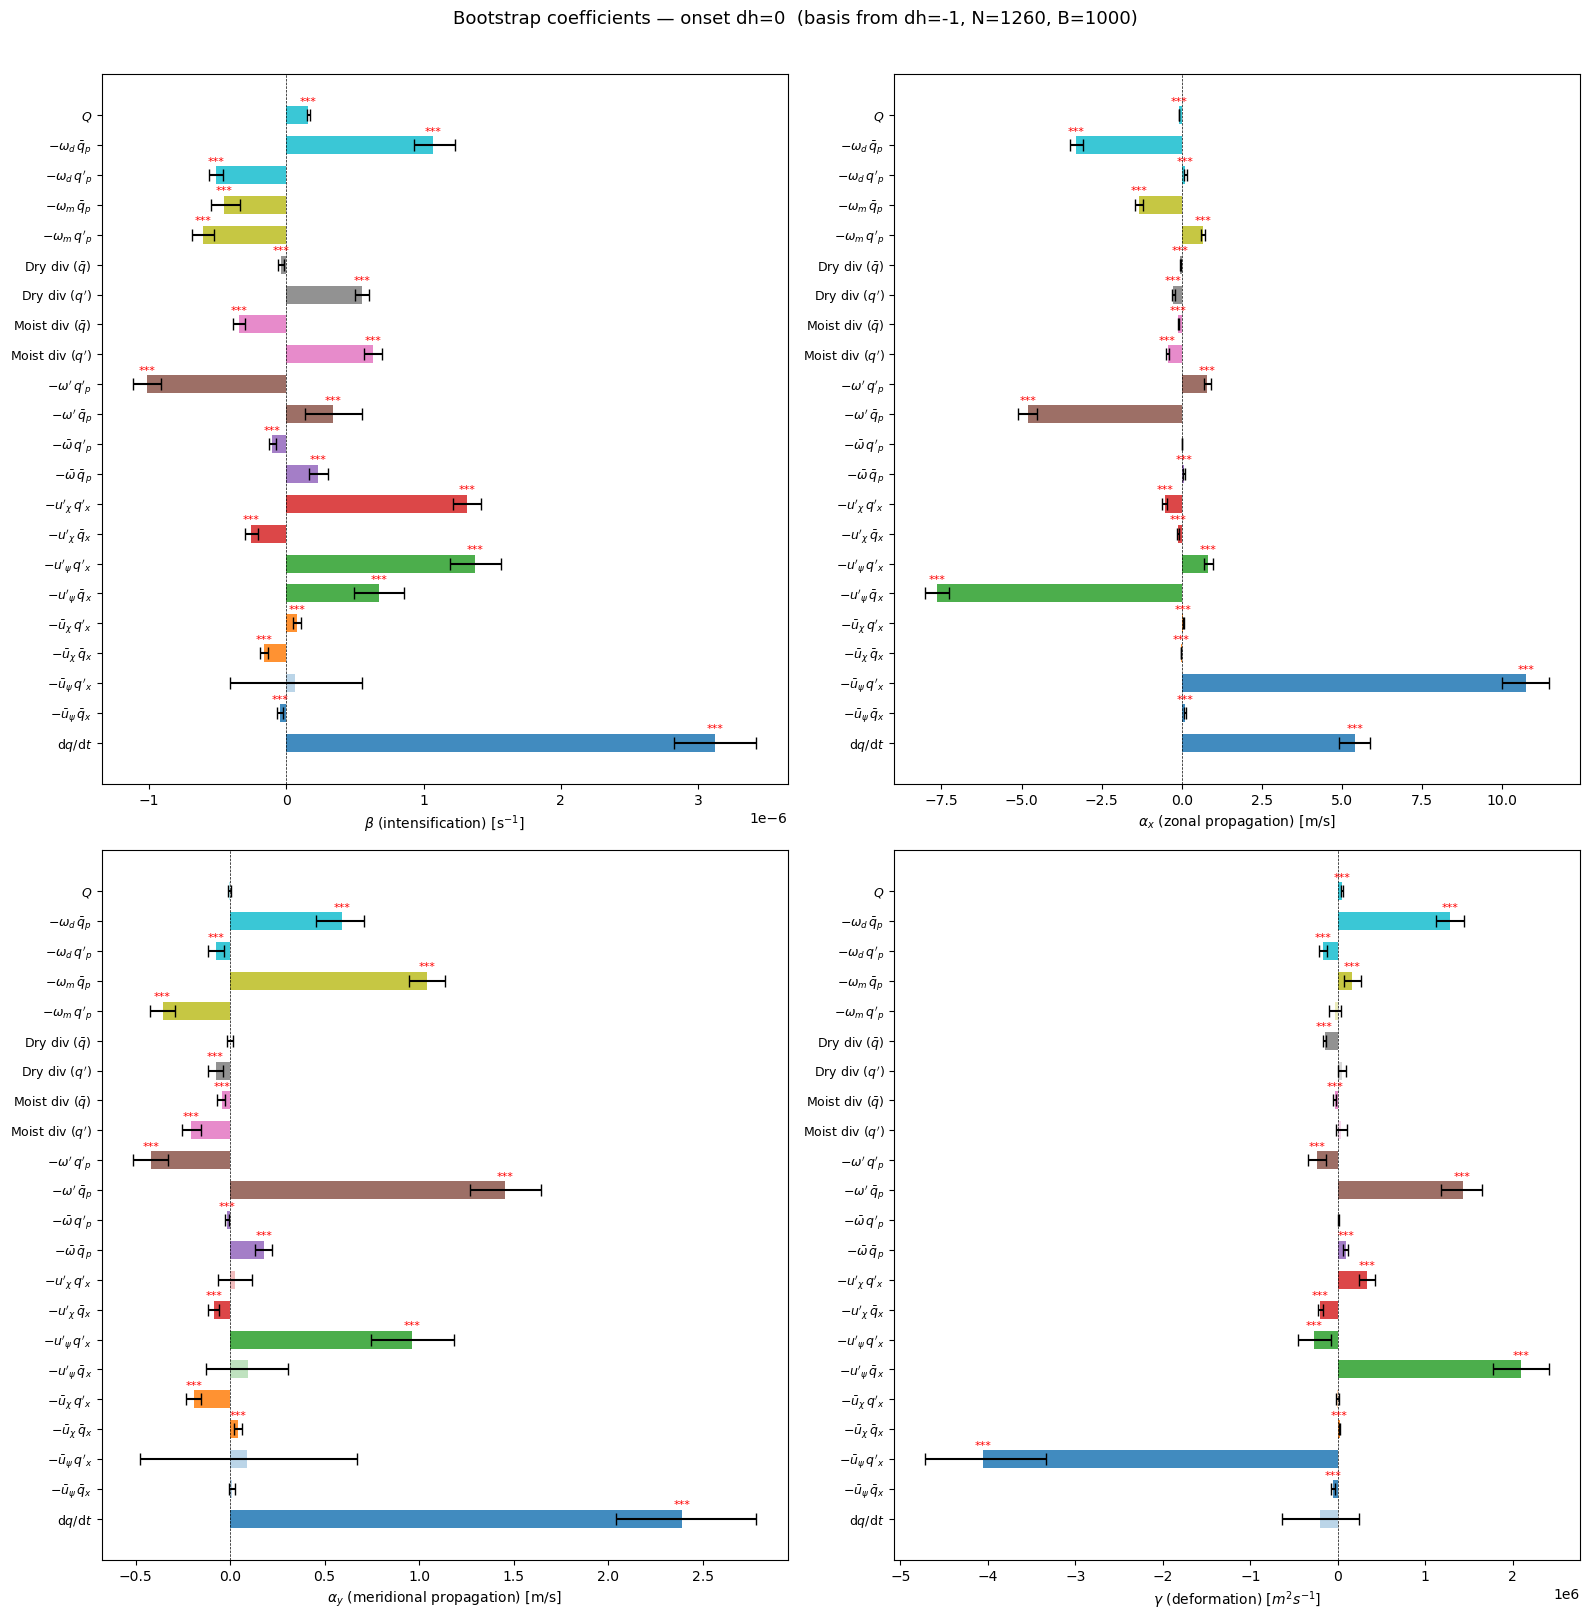

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
coef_names = ["beta", "ax", "ay", "gamma"]
coef_labels = [r"$\beta$ (intensification) [s$^{-1}$]",
               r"$\alpha_x$ (zonal propagation) [m/s]",
               r"$\alpha_y$ (meridional propagation) [m/s]",
               r"$\gamma$ (deformation) [$m^2s^{-1}$]"]

n_terms = len(TERMS)
colors = plt.cm.tab10(np.linspace(0, 1, n_terms))

for ax, cname, clabel in zip(axes.flat, coef_names, coef_labels):
    for i, (tname, bdata) in enumerate(boot_results.items()):
        vals = bdata[cname]
        mean = vals.mean()
        lo, hi = np.nanpercentile(vals, [2.5, 97.5])
        sig = lo * hi > 0  # CI excludes zero?

        ax.barh(i, mean, xerr=[[mean - lo], [hi - mean]],
                color=colors[i],
                alpha=0.85 if sig else 0.3,
                capsize=4, height=0.6)
        if sig:
            ax.text(mean, i + 0.35, "***", ha="center", fontsize=8, color="red")

    ax.set_yticks(range(n_terms))
    ax.set_yticklabels(TERM_NAMES, fontsize=9)
    ax.axvline(0, color="k", lw=0.5, ls="--")
    ax.set_xlabel(clabel, fontsize=10)

fig.suptitle(f"Bootstrap coefficients — {STAGE} dh={DH}  "
             f"(basis from dh={DH_BASIS}, N={n_events}, B={N_BOOT})",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Summary

- **25 PV-tendency terms** (dq/dt + 20 Helmholtz-partitioned advection + 4 moist/dry divergent partitions + Q)
  projected onto the four-basis decomposition.
- **5 horizontal wind groups**: ū_ψ, ū_χ, u'ₛ, u'ₜₕ, plus **vertical** (ω̄, ω').
  Each × 2 PV gradient (q̄, q') = 20 advection cross-terms.
- Basis built from **dh−1** composite mean (predictive framing), Gaussian smoothing.
- **Bootstrap resampling** (N=1000) provides 95 % confidence intervals;
  bars are opaque when the CI excludes zero (significant at p < 0.05).
- **Data**: `composite_blocking_tempest/onset`.

## 7  Closure check: full advection budget (Helmholtz-partitioned)

Verify that the **20 rot/div-partitioned advection cross-terms** (5 wind groups × 4
bar/anom combinations) plus diabatic heating $Q$ close the PV budget:

$$
\underbrace{\frac{\partial q'}{\partial t}
+ \frac{\partial \bar{q}}{\partial t}}_{\text{LHS (tendency)}}
\;\approx\;
\underbrace{-\sum_{\substack{\psi/\chi \\ \text{bar/anom}}}
\mathbf{u}_i \cdot \nabla q_j
\;-\; \omega_k \frac{\partial q_j}{\partial p}
\;+\; Q}_{\text{RHS (20 advection + Q)}}
$$

**5 wind groups**: $\bar{u}_\psi$, $\bar{u}_\chi$, $u'_\psi$, $u'_\chi$, $\omega$ (bar+anom).
Each × 4 PV gradient combos (bar/anom × zonal/merid or bar/anom × vert) = **20 terms**.

Residual = LHS − RHS is bootstrapped; dots mark grid points where
the 1.5 σ CI on the residual **excludes zero** (significant imbalance).

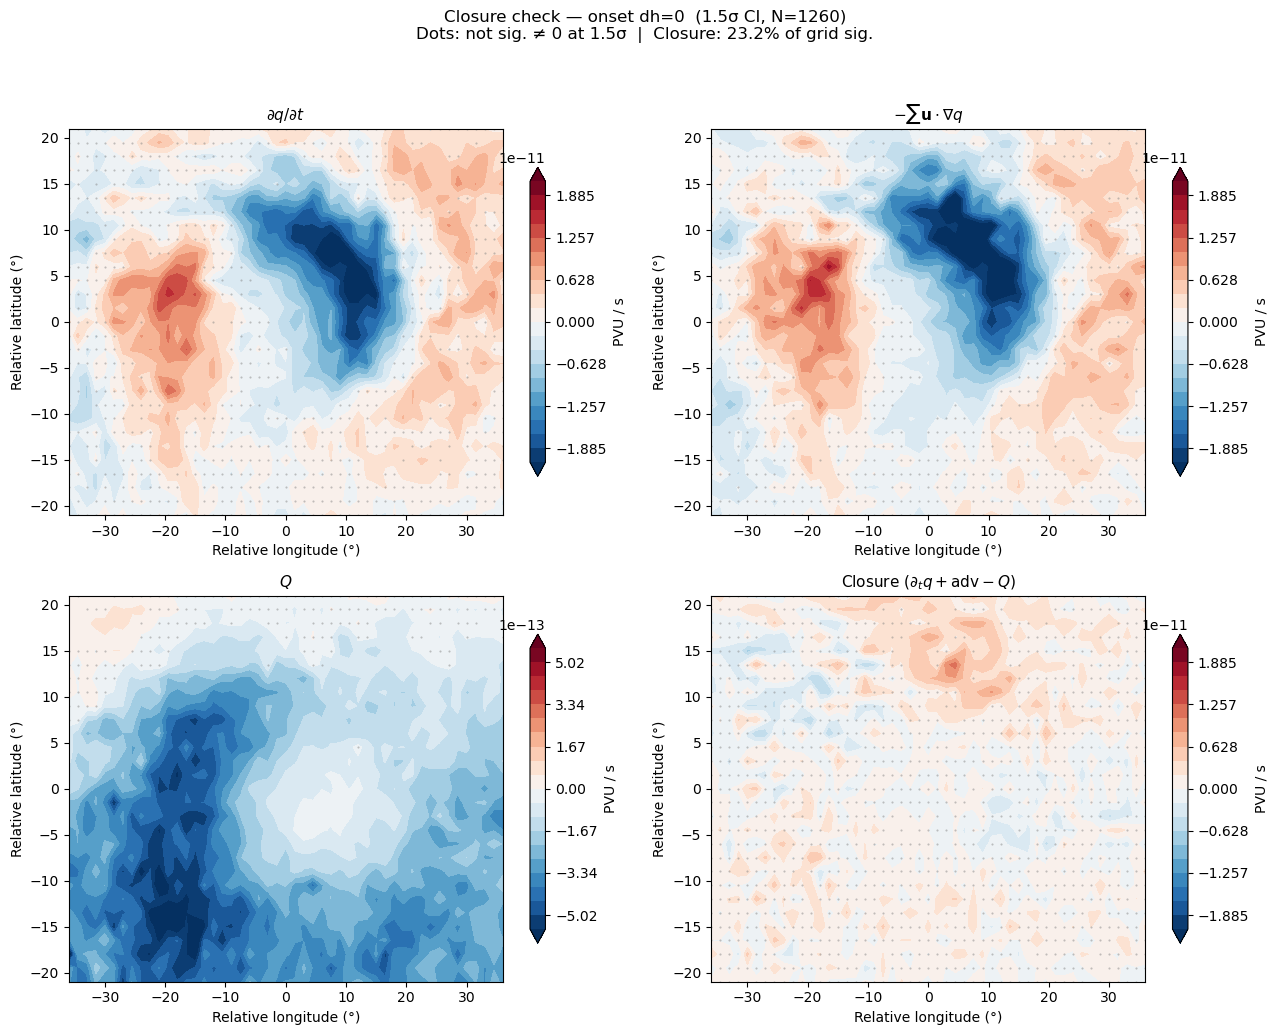

Grid points with sig. imbalance (1.5σ): 330/1421 (23.2%)
Mean |dq/dt|:     4.457e-12
Mean |residual|:  1.772e-12
Mean |rel. res|:  192.9%


In [12]:
# ── All 20 Helmholtz-partitioned advection cross-terms ──
# 5 wind groups × 4 bar/anom cross-terms = 20
# u_bar = u_rot_bar + u_div_bar;  u_anom = u_anom_rot + u_anom_div
# so the sum of these 20 ≡ the original 12 base terms.
# ADV_KEYS = [
#     # Clim rotational  (ū_ψ)
#     "u_rot_bar_pv_bar_dx",   "u_rot_bar_pv_anom_dx",
#     "v_rot_bar_pv_bar_dy",   "v_rot_bar_pv_anom_dy",
#     # Clim divergent   (ū_χ)
#     "u_div_bar_pv_bar_dx",   "u_div_bar_pv_anom_dx",
#     "v_div_bar_pv_bar_dy",   "v_div_bar_pv_anom_dy",
#     # Anom rotational  (u'_ψ)
#     "u_anom_rot_pv_bar_dx",  "u_anom_rot_pv_anom_dx",
#     "v_anom_rot_pv_bar_dy",  "v_anom_rot_pv_anom_dy",
#     # Anom divergent   (u'_χ)
#     "u_anom_div_pv_bar_dx",  "u_anom_div_pv_anom_dx",
#     "v_anom_div_pv_bar_dy",  "v_anom_div_pv_anom_dy",
#     # Vertical (ω bar + anom)
#     "w_bar_pv_bar_dp",       "w_bar_pv_anom_dp",
#     "w_anom_pv_bar_dp",      "w_anom_pv_anom_dp",
# ]

ADV_KEYS = [
    "u_bar_pv_anom_dx",  "u_bar_pv_bar_dx",
    "u_anom_pv_anom_dx", "u_anom_pv_bar_dx",
    "v_bar_pv_anom_dy",  "v_bar_pv_bar_dy",
    "v_anom_pv_anom_dy", "v_anom_pv_bar_dy",
    "w_bar_pv_anom_dp",  "w_bar_pv_bar_dp",
    "w_anom_pv_anom_dp", "w_anom_pv_bar_dp",
]

def _lhs(e):
    """LHS = dq'/dt + dq̄/dt."""
    return e["pv_anom_dt"] + e["pv_bar_dt"]

def _neg_adv(e):
    """Negated sum of 20 Helmholtz-partitioned advection cross-terms."""
    return -sum(e[k] for k in ADV_KEYS)

def _Q(e):
    return e["Q"]

def _residual(e):
    """Closure residual = dq/dt + Σ(adv) − Q."""
    return _lhs(e) + sum(e[k] for k in ADV_KEYS) - e["Q"]

# ── Bootstrap all four fields ──
from scipy.stats import norm

N_BOOT_CL = 1000
rng_cl = np.random.default_rng(99)
n_ev = len(events)

panel_funcs = {
    r"$\partial q/\partial t$": _lhs,
    r"$-\sum \mathbf{u}\cdot\nabla q$": _neg_adv,
    r"$Q$": _Q,
    r"Closure ($\partial_t q + \mathrm{adv} - Q$)": _residual,
}

p_lo = norm.cdf(-1.5) * 100  # ≈ 6.68
p_hi = norm.cdf( 1.5) * 100  # ≈ 93.32

panel_data = {}  # name → (mean, sig_mask)
for name, func in panel_funcs.items():
    stack = np.array([func(e) for e in events])
    mean = np.nanmean(stack, axis=0)
    boot = np.empty((N_BOOT_CL, *mean.shape))
    for b in range(N_BOOT_CL):
        idx = rng_cl.integers(0, n_ev, size=n_ev)
        boot[b] = np.nanmean(stack[idx], axis=0)
    ci_lo = np.nanpercentile(boot, p_lo, axis=0)
    ci_hi = np.nanpercentile(boot, p_hi, axis=0)
    sig = ~((ci_lo <= 0) & (ci_hi >= 0))
    panel_data[name] = (mean, sig)

# ── Colour scales: shared for dq/dt, adv, closure; separate for Q ──
panel_names = list(panel_funcs.keys())
shared_names = [n for n in panel_names if n != r"$Q$"]
vmax_shared = max(np.nanpercentile(np.abs(panel_data[n][0]), 98)
                  for n in shared_names)
vmax_Q = np.nanpercentile(np.abs(panel_data[r"$Q$"][0]), 98)

# Explicitly symmetric levels
N_LEV = 21
levs_shared = np.linspace(-vmax_shared, vmax_shared, N_LEV)
levs_Q      = np.linspace(-vmax_Q, vmax_Q, N_LEV)

# ── Plot 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, name in zip(axes.flat, panel_names):
    mean, sig = panel_data[name]
    levs = levs_Q if name == r"$Q$" else levs_shared
    cf = ax.contourf(X_rel, Y_rel, mean, levels=levs,
                     cmap="RdBu_r", extend="both")
    # Dot non-significant regions
    not_sig = ~sig
    if not_sig.any():
        ax.plot(X_rel[not_sig], Y_rel[not_sig], '.', color='grey',
                markersize=1.0, alpha=0.5)
    plt.colorbar(cf, ax=ax, shrink=0.8, label="PVU / s")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Relative longitude (°)")
    ax.set_ylabel("Relative latitude (°)")

lhs_mean = panel_data[panel_names[0]][0]
res_mean, res_sig = panel_data[panel_names[-1]]
frac_sig = res_sig.sum() / res_sig.size * 100
fig.suptitle(f"Closure check — {STAGE} dh={DH}  (1.5σ CI, N={n_ev})\n"
             f"Dots: not sig. ≠ 0 at 1.5σ  |  Closure: {frac_sig:.1f}% of grid sig.",
             fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

print(f"Grid points with sig. imbalance (1.5σ): "
      f"{res_sig.sum()}/{res_sig.size} ({frac_sig:.1f}%)")
print(f"Mean |dq/dt|:     {np.nanmean(np.abs(lhs_mean)):.3e}")
print(f"Mean |residual|:  {np.nanmean(np.abs(res_mean)):.3e}")
print(f"Mean |rel. res|:  {np.nanmean(np.abs(res_mean / (np.abs(lhs_mean) + 1e-30))) * 100:.1f}%")